# Business Problem

A company is investing in multiple digital marketing campaigns but lacks clarity on which factors are driving customer conversions.
They need to analyze customer demographics, engagement metrics, and campaign performance to identify key drivers of success.
The objective is to optimize marketing spend by focusing on high-performing channels and strategies.
This will enable improved conversion rates and maximize return on investment (ROI).


In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'C:\Users\Dell\Desktop\Projects2\Digital Marketing Compaign\digital_market.csv')
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [4]:
df.shape

(8000, 20)

> The dataset has a shape of (8000, 20), which means it contains 8,000 samples and 20 features.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [6]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')

In [9]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

# **Data Cleaning**

In [10]:
df_clean = df.drop('CustomerID', axis=1)

In [11]:
df = df_clean 
df.head()


,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


# **Exploratory Data Analysis (EDA) and Preprocessing**

In [12]:
np.unique(df['Gender'])

array(['Female', 'Male'], dtype=object)

In [13]:
np.unique(df['Age'])

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69], dtype=int64)

This shows that the `Age` column contains **ages ranging from 18 to 69 years old**.  
The dataset includes customers across a wide age range, which allows for detailed analysis of age-related trends in conversion rates.

##  -> Conversion Rate Analysis by Age and Gender

In [14]:
age_gender = df.groupby(['Age', 'Gender'])['ConversionRate'].mean().reset_index()
age_gender

,Age,Gender,ConversionRate
0,18,Female,0.115038
1,18,Male,0.095472
2,19,Female,0.096125
3,19,Male,0.109804
4,20,Female,0.099159
...,...,...,...
99,67,Male,0.115455
100,68,Female,0.107328
101,68,Male,0.103549
102,69,Female,0.095346


In [15]:
age_gender = df.groupby(['Age', 'Gender'])['ConversionRate'].max().reset_index()
age_gender

,Age,Gender,ConversionRate
0,18,Female,0.199252
1,18,Male,0.197427
2,19,Female,0.196636
3,19,Male,0.197036
4,20,Female,0.193630
...,...,...,...
99,67,Male,0.191359
100,68,Female,0.198614
101,68,Male,0.191700
102,69,Female,0.199583


In [16]:
max_conversion = age_gender.loc[age_gender['ConversionRate'].idxmax()]
max_conversion

Age                     55
Gender              Female
ConversionRate    0.199995
Name: 74, dtype: object

 - This identifies the row with the **highest Conversion Rate** in the `age_gender` DataFrame.  
  The result shows the `Age`, `Gender`, and `ConversionRate` for the group with the maximum conversion.  



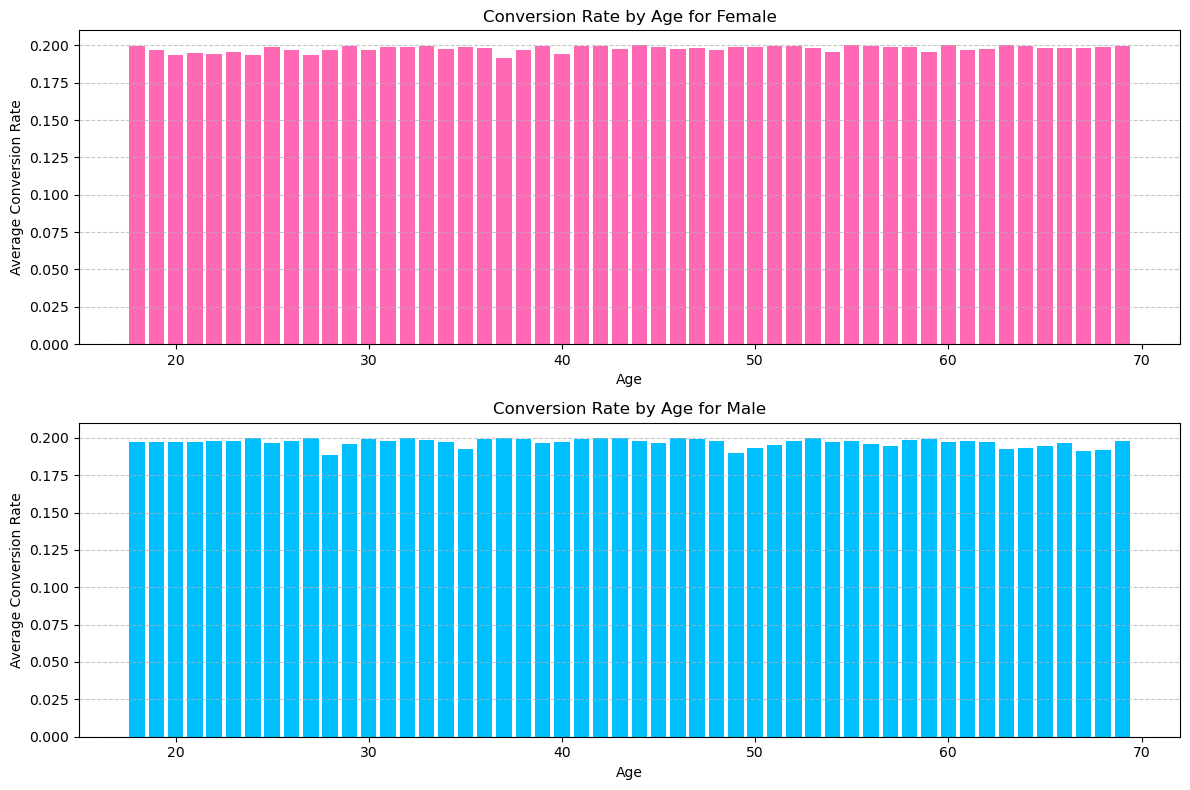

In [17]:
unique_genders = age_gender['Gender'].unique()

fig, axes = plt.subplots(len(unique_genders),1, figsize=(12,8))
colors = {'Male': 'Deepskyblue', 'Female': 'Hotpink'}

for i, gender in enumerate(unique_genders):
    data = age_gender[age_gender['Gender'] == gender]
    axes[i].bar(data['Age'], data['ConversionRate'], color=colors[gender])
    axes[i].set_title(f'Conversion Rate by Age for {gender}')
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('Average Conversion Rate')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- Each chart displays the conversion rate by `age` for that specific `gender`, making it easy to identify trends or differences in conversion rates between genders and age groups.

# -> Feature Engineering 

In [18]:
bins = [18, 28, 38, 48, 58, 68, 70]  
labels = ['18-27', '28-37', '38-47', '48-57', '58-67', '68-69']

In [19]:
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [20]:
age_group = df.groupby('AgeGroup')['ConversionRate'].mean()
age_group

AgeGroup
18-27    0.102614
28-37    0.102993
38-47    0.105454
48-57    0.103894
58-67    0.107538
68-69    0.100973
Name: ConversionRate, dtype: float64

In [21]:
max_conversion_age_group = age_group.idxmax()
max_conversion_age_group

'58-67'

- Useful for data-driven decision-making, such as targeting the most responsive age group in marketing campaigns.

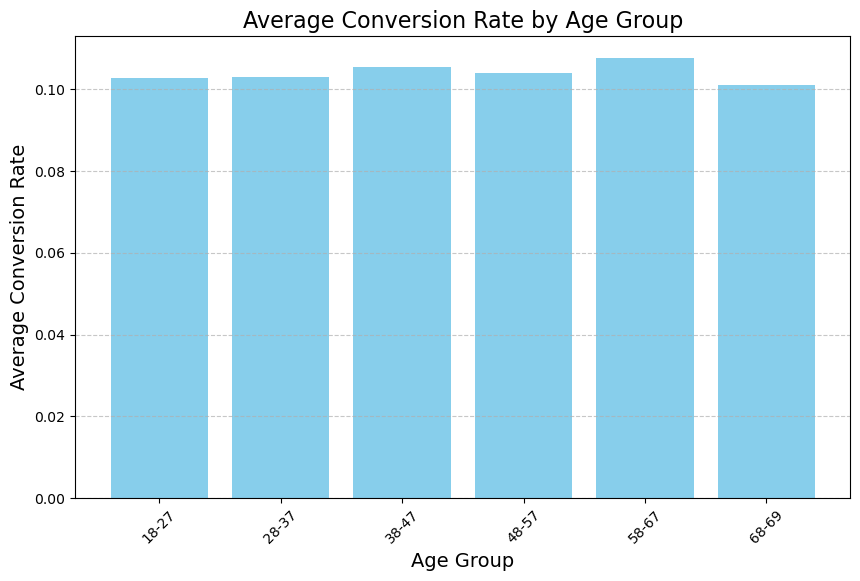

In [22]:
age_group = df.groupby('AgeGroup')['ConversionRate'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(age_group['AgeGroup'], age_group['ConversionRate'], color='skyblue')
plt.title('Average Conversion Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Average Conversion Rate', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## -> Heatmap

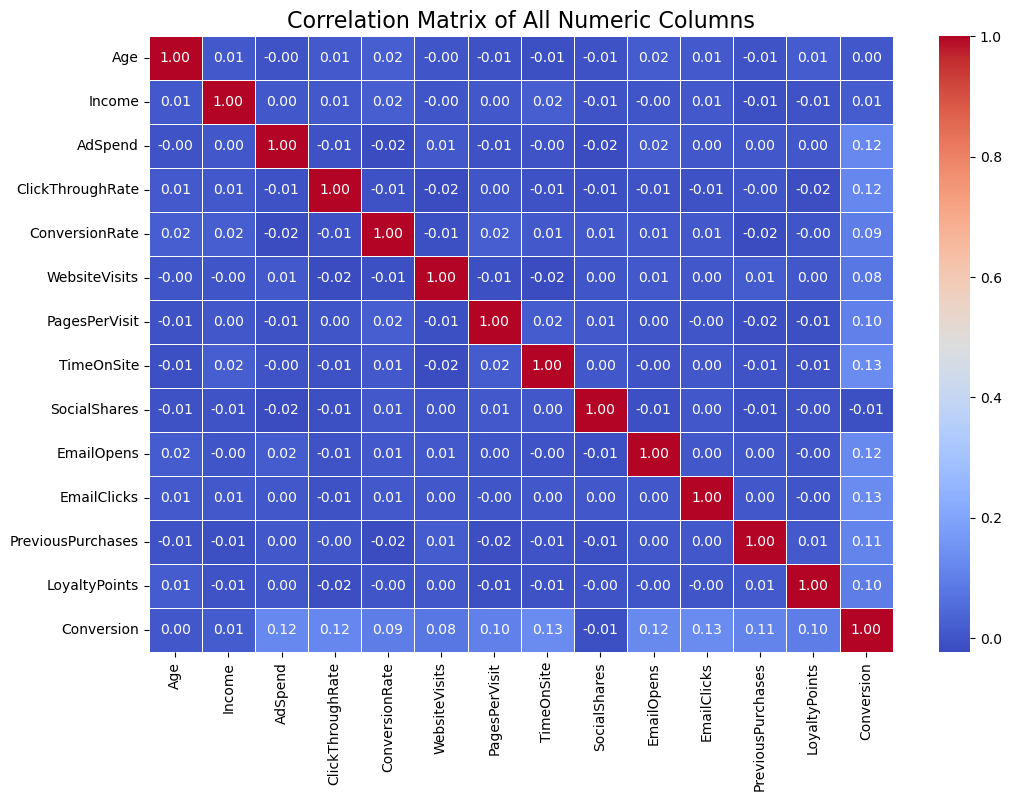

In [23]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of All Numeric Columns', fontsize=16)
plt.show()

## 📊 **Analysis of Campaign Channels and Conversion Rates**

#### -> **Max Conversion Rate**

In [24]:
df['ConversionRate'].max()

0.1999947079999166

In [25]:
max_conversion_index = df['ConversionRate'].idxmax()
max_conversion_index 

317

In [26]:
max_conversion_row = df.loc[max_conversion_index]
max_conversion_row

Age                             55
Gender                      Female
Income                       30006
CampaignChannel                SEO
CampaignType            Conversion
AdSpend                1758.082551
ClickThroughRate          0.110989
ConversionRate            0.199995
WebsiteVisits                   43
PagesPerVisit             9.492133
TimeOnSite               12.580665
SocialShares                    38
EmailOpens                       8
EmailClicks                      4
PreviousPurchases                6
LoyaltyPoints                 2907
AdvertisingPlatform       IsConfid
AdvertisingTool         ToolConfid
Conversion                       1
AgeGroup                     48-57
Name: 317, dtype: object

In [27]:
np.unique(df['CampaignChannel'])

array(['Email', 'PPC', 'Referral', 'SEO', 'Social Media'], dtype=object)

In [28]:
channel_conversion = df.groupby('CampaignChannel')['ConversionRate'].max().reset_index()
channel_conversion

,CampaignChannel,ConversionRate
0,Email,0.199992
1,PPC,0.199727
2,Referral,0.199938
3,SEO,0.199995
4,Social Media,0.199886


### **Implications:**
- All channels are **equally effective** in attracting users with high conversion potential.  
- Businesses can leverage **multiple channels simultaneously** without worrying about one channel underperforming significantly compared to others.  

### **Additional Considerations:**
While all channels have similar maximum Conversion Rates, to gain more comprehensive insights, other factors should also be considered, such as:  
- **Number of Users per Channel**:  
  - Channels with higher traffic may have greater potential to generate more Conversions, even if their Conversion Rates are similar.  
- **Cost per Conversion**:  
  - Channels that require lower advertising budgets but deliver high Conversion Rates may be more cost-effective.  

## -> **Box Plot**

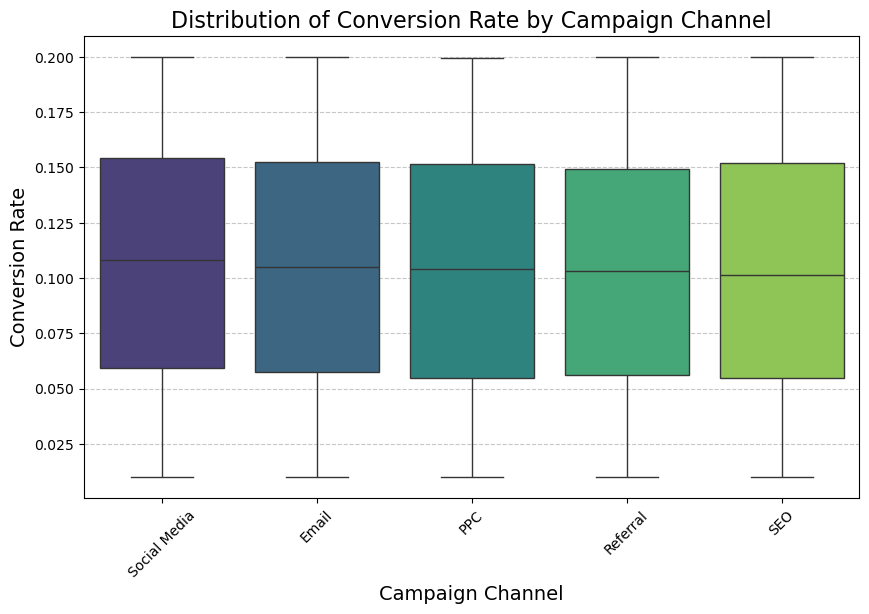

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='CampaignChannel', y='ConversionRate', data=df, palette='viridis')
plt.title('Distribution of Conversion Rate by Campaign Channel', fontsize=16)
plt.xlabel('Campaign Channel', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Calculate the Number of Users in Each Campaign Channel 

In [30]:
channel_counts = df['CampaignChannel'].value_counts().reset_index()
channel_counts.columns = ['CampaignChannel', 'UserCount']
channel_counts


,CampaignChannel,UserCount
0,Referral,1719
1,PPC,1655
2,Email,1557
3,SEO,1550
4,Social Media,1519


In [31]:
channel_summary = pd.merge(channel_counts, channel_conversion, on='CampaignChannel')
channel_summary

,CampaignChannel,UserCount,ConversionRate
0,Referral,1719,0.199938
1,PPC,1655,0.199727
2,Email,1557,0.199992
3,SEO,1550,0.199995
4,Social Media,1519,0.199886


### - Summary: Channels to Invest In

---

### 1. Channels with the Highest Conversion Rate

Email and SEO are the channels with the highest conversion rates, indicating they are highly effective in converting users into customers.  

---

### 2. Channels with the Highest User Count

Referral and PPC are the channels with the highest user counts, showing they can attract a large number of users.  

---

### Final Conclusion:
- Top Channels to Invest In: **Referral** and **PPC** due to their high user counts and strong conversion rates.  
- Channels to Further Optimize: **Email** and **SEO** to maximize their conversion rates.

# **# Group AdSpend**

In [32]:
df['AdSpendGroup'] = pd.cut(df['AdSpend'], bins=5)
adspend_group_conversion = df.groupby('AdSpendGroup')['ConversionRate'].mean().reset_index()
adspend_group_conversion


,AdSpendGroup,ConversionRate
0,"(90.157, 2079.627]",0.104714
1,"(2079.627, 4059.199]",0.106810
2,"(4059.199, 6038.771]",0.105057
3,"(6038.771, 8018.343]",0.103129
4,"(8018.343, 9997.915]",0.102121


## ->Calculate the Number of Users in Each AdSpend Group


In [33]:
adspend_group_counts = df['AdSpendGroup'].value_counts().reset_index()
adspend_group_counts.columns = ['AdSpendGroup', 'UserCount']
adspend_group_counts

,AdSpendGroup,UserCount
0,"(2079.627, 4059.199]",1660
1,"(90.157, 2079.627]",1623
2,"(6038.771, 8018.343]",1619
3,"(8018.343, 9997.915]",1559
4,"(4059.199, 6038.771]",1539


## -> Create a Box Plot to Analyze the Distribution of Conversion Rate by AdSpend Group

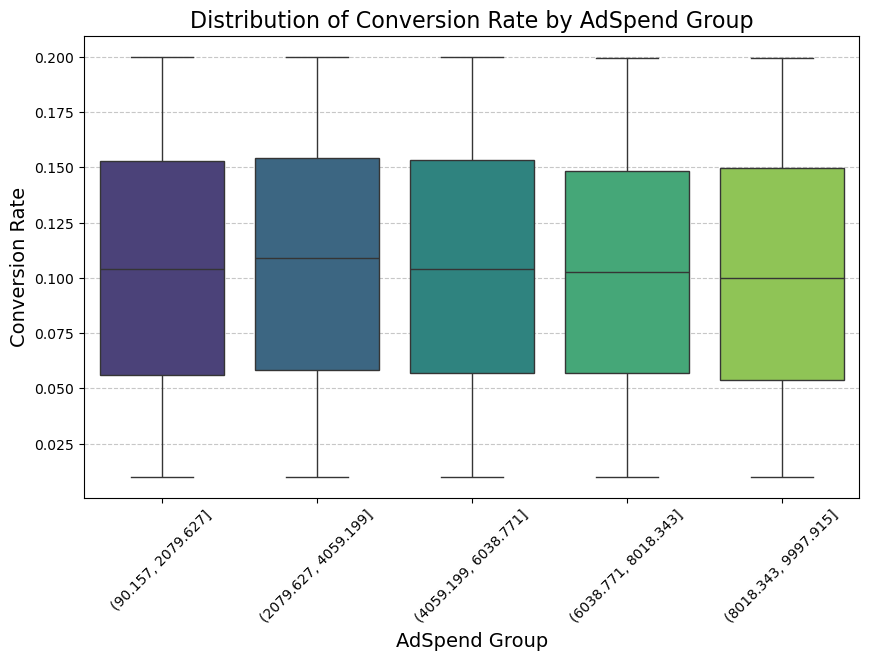

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='AdSpendGroup', y='ConversionRate', data=df, palette='viridis')
plt.title('Distribution of Conversion Rate by AdSpend Group', fontsize=16)
plt.xlabel('AdSpend Group', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- **Conversion Rate** across different **AdSpend Groups** shows a **similar distribution**.  
- **No AdSpend Group** stands out with significantly higher or lower Conversion Rates compared to others.  

# **# Calculate Average ClickThroughRate, TimeOnSite, and EmailClicks for Each AdSpend Group**


In [35]:
adspend_group_stats = df.groupby('AdSpendGroup').agg({
    'ClickThroughRate': 'mean',
    'TimeOnSite': 'mean',
    'EmailClicks': 'mean'
}).reset_index()


adspend_group_stats

,AdSpendGroup,ClickThroughRate,TimeOnSite,EmailClicks
0,"(90.157, 2079.627]",0.154551,7.744292,4.464572
1,"(2079.627, 4059.199]",0.157269,7.726103,4.459036
2,"(4059.199, 6038.771]",0.154821,7.798999,4.442495
3,"(6038.771, 8018.343]",0.153014,7.616229,4.425571
4,"(8018.343, 9997.915]",0.154411,7.757598,4.547146


In [36]:
df1= df.copy()
df1.to_csv('dashboard_data.csv', index=False)

# # ML Model

In [37]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [38]:
df_encoded.astype('int').head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,CampaignType_Retention,AgeGroup_28-37,AgeGroup_38-47,AgeGroup_48-57,AgeGroup_58-67,AgeGroup_68-69,"AdSpendGroup_(2079.627, 4059.199]","AdSpendGroup_(4059.199, 6038.771]","AdSpendGroup_(6038.771, 8018.343]","AdSpendGroup_(8018.343, 9997.915]"
0,56,136912,6497,0,0,0,2,7,19,6,...,0,0,0,1,0,0,0,0,1,0
1,69,41760,3898,0,0,42,2,5,5,2,...,1,0,0,0,0,1,1,0,0,0
2,46,88456,1546,0,0,2,8,13,0,11,...,0,0,1,0,0,0,0,0,0,0
3,32,44085,539,0,0,47,4,14,89,2,...,0,1,0,0,0,0,0,0,0,0
4,60,83964,1678,0,0,0,2,13,6,6,...,0,0,0,0,1,0,0,0,0,0


In [39]:
X = df_encoded.drop(['Conversion'], axis=1)
y = df_encoded['Conversion']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.715
              precision    recall  f1-score   support

           0       0.26      0.75      0.39       194
           1       0.95      0.71      0.81      1406

    accuracy                           0.71      1600
   macro avg       0.61      0.73      0.60      1600
weighted avg       0.87      0.71      0.76      1600



In [45]:
from sklearn.svm import SVC

model1 = SVC(class_weight='balanced')

model1.fit(X_train, y_train)

SVC(class_weight='balanced')

In [46]:
y_pred1 = model1.predict(X_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Accuracy: 0.80125
              precision    recall  f1-score   support

           0       0.33      0.62      0.43       194
           1       0.94      0.83      0.88      1406

    accuracy                           0.80      1600
   macro avg       0.63      0.72      0.65      1600
weighted avg       0.87      0.80      0.83      1600



# Save it

In [48]:
X_scaled = scaler.transform(X)

In [49]:
df['Probability'] = model.predict_proba(X_scaled)[:,1]
df['Prediction'] = model.predict(X_scaled)

In [50]:
df.to_csv('ml_dashboard.csv', index=False)

# Summary of Conversion Prediction Models

## 1. Importance of Conversion
Conversion is a crucial metric for measuring the effectiveness of marketing campaigns or business strategies. It reflects the success of turning users or visitors into customers or achieving desired actions (e.g., purchasing products, signing up, etc.). Accurate prediction of Conversion enables marketing teams or businesses to:
- **Improve marketing campaigns**: Identify high-conversion target groups to focus resources effectively.
- **Reduce costs**: Minimize unnecessary advertising expenses by targeting groups with high conversion potential.



## 2. Final Summary
The analysis successfully identified key factors influencing customer conversion in marketing campaigns.
Among the models tested, Logistic Regression performed better in identifying non-converting customers, helping reduce unnecessary marketing spend.
This enables the business to target the right audience more effectively and optimize overall campaign performance.